### Telco Churn Analysis & Machine Learning Pipeline

This notebook implements an end-to-end, reproducible classification study for customer churn prediction.

The experimental design includes:
- a stratified 80/20 development-test split with a fixed random seed;
- leakage-safe five-fold stratified cross-validation;
- comparison of imbalance-handling strategies;
- comparison of multiple classifier families against a majority-class baseline;
- hyperparameter tuning performed only on the development partition;
- decision-threshold selection from out-of-fold development predictions;
- final held-out test evaluation using complementary predictive metrics;
- statistical, calibration, error, fairness, explainability and business-value analyses; and
- persistence of the final deployment artefacts and software environment details.

**Evaluation principle.** The held-out test set is reserved for final evaluation. Model selection, resampling choices, hyperparameter tuning and threshold selection are performed using the development partition only.


In [ ]:
import os
import sys
import json
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Scikit-learn & ML imports
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score, cross_validate, cross_val_predict, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, confusion_matrix,
    average_precision_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, log_loss, brier_score_loss
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
N_JOBS = 1
np.random.seed(RANDOM_STATE)

os.makedirs("plotly_figs", exist_ok=True)

print("Environment successfully initialised.")
print(f"Random seed: {RANDOM_STATE}")
print(f"Parallel jobs: {N_JOBS}")

Environment successfully initialised.
Random seed: 42
Parallel jobs: 1


In [ ]:
DATA_PATH = "telcos.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df_raw.shape}")

df_raw.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Create a working copy of the raw dataset
df = df_raw.copy()

# Check customer ID uniqueness
if "customerID" in df.columns:
    print(f"Unique customer IDs: {df['customerID'].nunique():,} / {len(df):,}")
    print(f"Are all customer IDs unique? {df['customerID'].is_unique}")

df.head()

Unique customer IDs: 7,043 / 7,043
Are all customer IDs unique? True


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Convert TotalCharges from object to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check values that could not be converted
missing_total = df["TotalCharges"].isna()

print(f"Missing TotalCharges values: {missing_total.sum()}")

Missing TotalCharges values: 11


In [ ]:
# Examine customers with missing TotalCharges
df.loc[missing_total, ["tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


**Observation:** The missing `TotalCharges` values occur among customers with zero months of tenure. This suggests that these customers have not yet accumulated a total charge. The missing values were therefore replaced with zero rather than estimated using the wider customer population.

In [ ]:
# Replace missing TotalCharges values with zero
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Remove customerID as it is only a unique identifier
df = df.drop(columns=["customerID"])

print("TotalCharges cleaned and customerID removed.")

TotalCharges cleaned and customerID removed.


In [ ]:
# Check churn values before encoding
print("Churn values before encoding:")
print(df["Churn"].value_counts())

# Convert Churn from Yes/No to 1/0
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("\nChurn values after encoding:")
print(df["Churn"].value_counts())

Churn values before encoding:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn values after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Final checks after data cleaning

print("Final Data Quality Check")
print("-" * 30)

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(
    f"Identical feature rows after removing customerID: "
    f"{df.duplicated().sum()}"
)
print(f"Churn rate: {df['Churn'].mean():.2%}")

print("\nData types:")
print(df.dtypes)

Final Data Quality Check
------------------------------
Dataset shape: (7043, 20)
Missing values: 0
Identical feature rows after removing customerID: 22
Churn rate: 26.54%

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


### Data Quality Summary

After cleaning, the dataset contains 7,043 customer records with no remaining missing values. The overall churn rate is 26.54%, showing that churners form the minority class. The 22 identical rows observed after removing `customerID` were retained because they may represent different customers with the same recorded characteristics rather than true duplicate records. The cleaned dataset was therefore considered suitable for subsequent exploratory analysis and preprocessing.

### 2. Exploratory Data Analysis (Plotly Visualisations)

Let's do some visual analysis to understand customer behaviour before jumping straight into feature engineering.

We want to explore:
1. Target class imbalance.
2. The interaction between monthly charges, tenure, and churn likelihood.
3. How contract commitment types impact churn rate.

In [ ]:
# 1. Churn class distribution
churn_counts = df['Churn'].value_counts().sort_index().reset_index()
churn_counts.columns = ['Churn_Label', 'Count']
churn_counts['Status'] = churn_counts['Churn_Label'].map({0: 'Retained', 1: 'Churned'})
display(churn_counts[['Status', 'Count']])

fig_target = px.pie(
    churn_counts, values='Count', names='Status',
    title='Target Class Distribution (Subscriber Churn Rate)',
    color_discrete_sequence=['#2b5c8f', '#d9534f'], hole=0.4
)
fig_target.update_traces(textinfo='percent+label')
fig_target.show()


,Status,Count
0,Retained,5174
1,Churned,1869


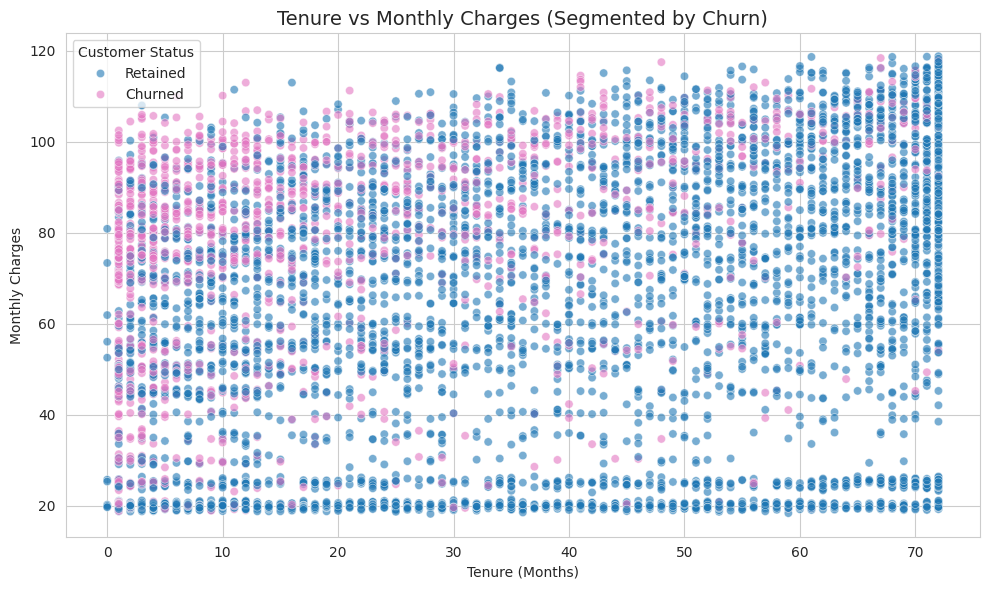

In [ ]:
#2a. Monthly Charges vs Tenure by Churn Status- Scatter plot

churn_label = df['Churn'].map({0: 'Retained', 1: 'Churned'})

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue=churn_label,
    palette={'Retained': '#1f77b4', 'Churned': '#e377c2'},
    alpha=0.6
)

# Titles and labels
plt.title('Tenure vs Monthly Charges (Segmented by Churn)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')

# Legend
plt.legend(title='Customer Status')

plt.tight_layout()
plt.show()

### Interpretation: Customer Density Across Tenure and Monthly Charges

The density heatmap shows clear differences in the distribution of retained and churned customers across tenure and monthly charges. Retained customers are distributed across a wider range of tenure values, with noticeable concentrations among customers with relatively low monthly charges and among long-tenure customers paying higher monthly charges.

Churned customers are more strongly concentrated at shorter tenure periods, particularly within moderate to high monthly charge ranges. As tenure increases, the concentration of churned customers generally becomes lower, indicating that customers in the earlier stages of their relationship with the provider appear more frequently within the churn group.

The visualisation also suggests that monthly charges should not be interpreted independently. High monthly charges are observed among both retained and churned customers, while the combination of shorter tenure and relatively high charges appears more prominent within the churned group. This indicates that the relationship between customer charges and churn may depend partly on tenure.

These patterns are exploratory and should not be interpreted as evidence of causation. Their predictive importance will therefore be assessed alongside other customer characteristics during the modelling stage.

In [ ]:
# 2b. Monthly Charges vs Tenure by Churn Status
fig = px.density_heatmap(
    df,
    x="tenure",
    y="MonthlyCharges",
    color_continuous_scale="Blues",
    nbinsx=30,
    nbinsy=30,
    title="Customer Density Across Tenure and Monthly Charges",
    labels={
        "tenure": "Customer Tenure (Months)",
        "MonthlyCharges": "Monthly Charges"
    }
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Customer Tenure (Months)",
    yaxis_title="Monthly Charges",
    coloraxis_colorbar_title="Customers"
)
fig.show()


### Customer Density Across Tenure and Monthly Charges

To better understand the relationship between customer tenure and monthly charges, a **density heatmap** was used instead of a traditional scatter plot. While scatter plots are useful for visualising relationships between two numerical variables, they become increasingly difficult to interpret when the dataset contains thousands of observations. This issue, known as **overplotting**, occurs when multiple data points overlap, making it challenging to identify underlying patterns or areas of high customer concentration.

A density heatmap addresses this limitation by dividing the plot into small regions (bins) and counting the number of customers that fall within each region. The colour intensity represents the concentration of customers, where darker shades indicate areas with a higher number of observations and lighter shades indicate lower concentrations. This approach provides a clearer representation of the overall distribution of customers across both tenure and monthly charges.

From this visualisation, several insights can be obtained:

- The darkest regions indicate where the majority of customers are concentrated, providing an overview of the typical customer profile.
- Areas with lower colour intensity represent less common combinations of tenure and monthly charges, making unusual customer segments easier to identify.
- The distribution of customers across different tenure and pricing levels helps determine whether there is an apparent relationship between these two variables before applying statistical or machine learning techniques.
- If customer density appears spread across multiple tenure and pricing ranges, it suggests that monthly charges alone are unlikely to explain customer churn, highlighting the need to examine additional variables such as contract type, payment method, internet service, and customer support interactions.

Overall, the density heatmap provides a more informative representation of the joint distribution of customer tenure and monthly charges than a scatter plot. By reducing visual clutter and emphasising customer concentration, it allows meaningful patterns to be identified more effectively during the exploratory data analysis (EDA) stage. The insights obtained from this visualisation guide subsequent feature analysis and support the selection of variables that may contribute to predicting customer churn.

In [ ]:
fig = px.density_heatmap(
    df,
    x="tenure",
    y="MonthlyCharges",
    facet_col=df["Churn"].map({
        0: "Retained",
        1: "Churned"
    }),
    nbinsx=30,
    nbinsy=30,
    color_continuous_scale="Blues",
    title="Customer Density Across Tenure and Monthly Charges by Churn Status",
    labels={
        "tenure": "Customer Tenure (Months)",
        "MonthlyCharges": "Monthly Charges",
        "count": "Customer Count"
    }
)

# Clean the facet headings
fig.for_each_annotation(
    lambda a: a.update(
        text=a.text.split("=")[-1]
    )
)

# Improve overall layout
fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=500,
    width=900,
    coloraxis_colorbar_title="Customer Count",
    margin=dict(
        l=70,
        r=60,
        t=90,
        b=80
    )
)

# Use one shared x-axis title instead of repeating it
fig.update_xaxes(title_text="")
fig.update_yaxes(title_text="Monthly Charges")

fig.add_annotation(
    text="Customer Tenure (Months)",
    x=0.5,
    y=-0.15,
    xref="paper",
    yref="paper",
    showarrow=False,
    font=dict(size=14)
)

fig.show()

In [ ]:
# 3. Contract Type vs Churn Rate
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn Rate (%)'] = contract_churn['Churn'] * 100

fig_contract = px.bar(
    contract_churn,
    x='Contract',
    y='Churn Rate (%)',
    color='Contract',
    title='Churn Rate by Contract Commitment Type',
    text_auto='.1f',
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig_contract.update_layout(template='plotly_white', showlegend=False)
fig_contract.show()

### Visual & Numerical Summary

Contract type is strongly associated with observed churn in this dataset. Month-to-month customers have the highest observed churn rate (about **42.7%**), compared with approximately **11.3%** for one-year contracts and **2.8%** for two-year contracts.

| Contract Type | Observed Churn Rate |
| :--- | ---: |
| Month-to-month | ~42.7% |
| One year | ~11.3% |
| Two year | ~2.8% |

These are descriptive associations, not causal effects. The dataset does not establish that changing a customer's contract would itself reduce churn, because customers who choose different contract types may also differ in tenure, service mix, price, payment method and other observed or unobserved characteristics. Contract type is therefore treated as a potentially informative predictor rather than as a proven retention intervention.

### 3. Feature Engineering Strategy

Four deterministic features are added before modelling. None uses the churn label. The original variables are retained so the engineered features can be evaluated as complementary representations rather than assumed improvements.

1. **`TotalServices`**: count of six optional add-on services. This provides a compact summary of service breadth.
2. **`TenureCohort`**: tenure grouped into 0-12, 12-24, 24-48 and 48+ month bands while retaining continuous tenure. This allows models to capture broad lifecycle stages.
3. **`ChargeRatio`**: `TotalCharges / (MonthlyCharges × tenure)` when tenure is positive. This is a billing-consistency feature, not a measure of profitability.
4. **`AutoPayment`**: indicator for automatic bank transfer or credit-card payment. This groups payment methods into automatic versus manual categories.

Any predictive value of these features is assessed later using cross-validation rather than inferred from their construction.

In [ ]:
df_fe = df.copy()

# List of optional tech add-ons
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
# 1. Total services count
df_fe['TotalServices'] = df_fe[service_cols].apply(lambda row: sum(row == 'Yes'), axis=1)


`TotalServices` is calculated by counting how many of six optional services are active for each customer, giving a value from 0 to 6. The feature is intended to summarise service breadth in an interpretable form while leaving the original service indicators available to the models. It is a descriptive representation of the observed service mix and should not be interpreted as a causal measure of customer "stickiness".


In [ ]:
# Create tenure cohorts

# Group customers into tenure cohorts
df_fe["TenureCohort"] = pd.cut(
    df_fe["tenure"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=[
        "0-12 Months",
        "12-24 Months",
        "24-48 Months",
        "48+ Months"
    ]
)

print("Tenure cohort distribution:"); print()
print(df_fe["TenureCohort"].value_counts().sort_index())

Tenure cohort distribution:

TenureCohort
0-12 Months     2186
12-24 Months    1024
24-48 Months    1594
48+ Months      2239
Name: count, dtype: int64


#### Tenure Cohorts

Customer tenure was grouped into four lifecycle periods to provide a categorical representation of how long each customer had remained with the provider. The original continuous `tenure` variable was retained, allowing the models to use both the exact tenure value and the broader lifecycle grouping.

In [ ]:
# Cell 2: Create the charge-ratio feature
# Compare accumulated charges with the amount expected from tenure
expected_total = df_fe["MonthlyCharges"] * df_fe["tenure"]

df_fe["ChargeRatio"] = np.where(
    expected_total > 0,
    df_fe["TotalCharges"] / expected_total,
    1.0
)

print(df_fe["ChargeRatio"].describe())

count    7043.000000
mean        1.000274
std         0.051119
min         0.689356
25%         0.979623
50%         1.000000
75%         1.019491
max         1.573454
Name: ChargeRatio, dtype: float64


#### Charge Ratio

A charge-ratio feature was created by comparing each customer's recorded `TotalCharges` with `MonthlyCharges × tenure`. The feature provides a simple indication of how accumulated charges relate to the customer's current monthly charge and tenure.

This ratio should not be interpreted as a formal billing-consistency measure because monthly charges may have changed during a customer's relationship with the provider. For customers with zero tenure, the ratio was set to 1 to avoid division by zero.

In [ ]:
# Identify customers using automatic payment methods
auto_payments = [
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

df_fe["AutoPayment"] = (
    df_fe["PaymentMethod"]
    .isin(auto_payments)
    .astype(int)
)

print("Auto-payment distribution:")
print(df_fe["AutoPayment"].value_counts())

print(
    f"\nCustomers using automatic payment: "
    f"{df_fe['AutoPayment'].mean():.1%}"
)

Auto-payment distribution:
AutoPayment
0    3977
1    3066
Name: count, dtype: int64

Customers using automatic payment: 43.5%


#### Automatic Payment

A binary `AutoPayment` feature was created to distinguish customers using automatic bank transfer or credit-card payments from those using manual payment methods. The original `PaymentMethod` variable was retained for subsequent categorical encoding.

In [ ]:
# Cell 4: Identify and encode categorical variables
# Identify categorical columns
cat_cols = df_fe.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print(f"Categorical columns found: {len(cat_cols)}")
print(cat_cols)



Categorical columns found: 16
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureCohort']


In [ ]:
# Cell 5: One-hot encode categorical variables

# One-hot encode the categorical variables
df_encoded = pd.get_dummies(
    df_fe,
    columns=cat_cols,
    drop_first=True
)

print(f"Shape before encoding: {df_fe.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")

Shape before encoding: (7043, 24)
Shape after encoding:  (7043, 37)


#### Categorical Encoding

Categorical variables were converted into numerical indicator variables using one-hot encoding. The first category from each variable was dropped to avoid redundant dummy variables while retaining the information required for modelling.

In [ ]:
# Cell 6: Separate predictors and target
# Separate predictors and target

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print(f"Predictor matrix (X): {X.shape}")
print(f"Target vector (y):    {y.shape}")


Predictor matrix (X): (7043, 36)
Target vector (y):    (7043,)


In [ ]:
# Cell 7: Final feature-engineering check

# Final check after feature engineering and encoding

print("Feature Engineering Summary")
print("-" * 30)

print(f"Customer records:       {len(df_encoded):,}")
print(f"Predictor variables:    {X.shape[1]}")
print(f"Categorical variables:  {len(cat_cols)}")
print(f"Missing values in X:    {X.isnull().sum().sum()}")
print(f"Overall churn rate:     {y.mean():.2%}")

Feature Engineering Summary
------------------------------
Customer records:       7,043
Predictor variables:    36
Categorical variables:  16
Missing values in X:    0
Overall churn rate:     26.54%


In [ ]:
# Visualise engineered feature relationship: Total Services vs Churn Rate
service_churn = df_fe.groupby('TotalServices')['Churn'].agg(['mean', 'count']).reset_index()
service_churn['Churn Rate (%)'] = service_churn['mean'] * 100

fig_services = px.bar(
    service_churn,
    x='TotalServices',
    y='Churn Rate (%)',
    title='Impact of Active Add-on Services on Subscriber Churn Rate',
    text_auto='.1f',
    labels={'TotalServices': 'Number of Active Add-on Services'},
    color='Churn Rate (%)',
    color_continuous_scale='Reds'
)
fig_services.update_layout(template='plotly_white')
fig_services.show()

### Visual & Numerical Summary

The relationship between the number of optional services and churn is not monotonic at the lower end of the distribution. Customers with one active add-on have the highest observed churn rate (about **45.8%**), compared with **21.4%** among customers with no active add-ons. Churn then declines across higher service counts, reaching approximately **5.3%** among customers with all six add-ons.

| Active Add-on Services | Observed Churn Rate |
| :--- | ---: |
| 0 | ~21.4% |
| 1 | ~45.8% |
| 2 | ~35.8% |
| 3 | ~27.4% |
| 4 | ~22.3% |
| 5 | ~12.4% |
| 6 | ~5.3% |

This pattern justifies retaining both the original service variables and the engineered count for modelling. It does **not** establish that adding services would cause churn to fall, because service uptake is not randomly assigned and may be associated with other customer characteristics.

### 4. Modelling Framework and Stratified Cross-Validation

Model development used stratified cross-validation to preserve the proportion of churned and retained customers within each fold. This is particularly important because churn represents the minority class in the dataset.

Where SMOTE was evaluated, it was applied within an `imbalanced-learn` pipeline so that synthetic samples were generated using only the training portion of each cross-validation fold. Applying SMOTE before cross-validation could allow information from validation observations to influence the resampling process and produce overly optimistic performance estimates.

Preprocessing and resampling steps were therefore kept within the cross-validation pipeline where applicable, while the held-out test set remained separate from model development and was reserved for final evaluation.

In [ ]:
# Split the data into development and held-out test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

FEATURE_NAMES = X_train.columns.tolist()

print(f"Development rows: {len(X_train):,}")
print(f"Held-out test rows: {len(X_test):,}")
print(f"Development churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")

Development rows: 5,634
Held-out test rows: 1,409
Development churn rate: 0.265
Test churn rate: 0.265


#### Train-Test Split

The dataset was divided into an 80% development set and a 20% held-out test set using stratified sampling. Stratification was used to preserve the churn distribution across both partitions. The test set was reserved for final evaluation and was not used during model, resampling-strategy, hyperparameter or threshold selection.

In [ ]:
# Five-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Cross-validation strategy: 5-fold StratifiedKFold")

Cross-validation strategy: 5-fold StratifiedKFold


In [ ]:
# Build a leakage-safe modelling pipeline
def build_pipeline(classifier, sampler="smote", scale=True):

    steps = []

    if scale:
        steps.append(("scaler", StandardScaler()))

    if sampler == "smote":
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))

    steps.append(("clf", classifier))

    return ImbPipeline(steps)

#### Leakage-Safe Pipeline

Preprocessing and SMOTE were placed inside an `imbalanced-learn` pipeline so that each step is fitted independently within every cross-validation fold. This prevents information from the validation fold influencing scaling or synthetic oversampling.

In [ ]:
# Candidate models for the initial comparison
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=12,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        n_estimators=120,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=N_JOBS
    ),


    "MLP Neural Network": MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=RANDOM_STATE
),
}

print(f"Number of candidate models: {len(baseline_models)}")

Number of candidate models: 8


A simple multilayer perceptron (MLP) neural-network baseline was also included to provide an empirical comparison between conventional tabular models and a neural approach, without expanding the project into a full deep-learning implementation.

In [ ]:
# Run cross-validation
scoring = {
    "f1": "f1",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

cv_results = {}

for name, model in baseline_models.items():

    scores = cross_validate(
        build_pipeline(model),
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS,
        return_train_score=False
    )

    cv_results[name] = {
        "F1_mean": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(),
        "Recall_mean": scores["test_recall"].mean(),
        "AUC_mean": scores["test_roc_auc"].mean(),
        "F1_folds": scores["test_f1"].tolist()
    }

    print(
        f"{name:20s} | "
        f"F1: {scores['test_f1'].mean():.4f} "
        f"+/- {scores['test_f1'].std():.4f} | "
        f"Recall: {scores['test_recall'].mean():.4f} | "
        f"ROC-AUC: {scores['test_roc_auc'].mean():.4f}"
    )

Logistic Regression  | F1: 0.6295 +/- 0.0185 | Recall: 0.7886 | ROC-AUC: 0.8444
Decision Tree        | F1: 0.6090 +/- 0.0171 | Recall: 0.7538 | ROC-AUC: 0.8201
Random Forest        | F1: 0.6288 +/- 0.0212 | Recall: 0.6763 | ROC-AUC: 0.8392
Extra Trees          | F1: 0.6260 +/- 0.0204 | Recall: 0.7043 | ROC-AUC: 0.8394
AdaBoost             | F1: 0.6332 +/- 0.0277 | Recall: 0.7244 | ROC-AUC: 0.8423
Gradient Boosting    | F1: 0.6290 +/- 0.0220 | Recall: 0.6722 | ROC-AUC: 0.8456
XGBoost              | F1: 0.6335 +/- 0.0219 | Recall: 0.7211 | ROC-AUC: 0.8461
MLP Neural Network   | F1: 0.5121 +/- 0.0094 | Recall: 0.5157 | ROC-AUC: 0.7630


### Cross-Validation Results

Eight candidate models were compared using the same <b>five-fold stratified cross-validation</b> procedure.

<b>XGBoost</b> achieved the highest mean F1-score (<b>0.6335</b>) and ROC-AUC (<b>0.8461</b>), while <b>Logistic Regression</b> produced the highest recall (<b>0.7886</b>) and remained competitive on F1 (<b>0.6295</b>).

The <b>MLP neural-network baseline</b> performed substantially worse than the strongest classical models, with F1 <b>0.5121</b> and ROC-AUC <b>0.7630</b>. This provides an empirical neural comparison without expanding the project into a deep-learning architecture study.

> <b>Development-stage conclusion:</b> Model complexity did not automatically improve performance. The held-out test set remains reserved for final evaluation.

### 5. Class Weighting and Imbalance Strategy Comparison

Class imbalance can be handled in different ways. Rather than assuming that one approach is automatically superior, three strategies are compared during model development: <b>no balancing</b>, <b>SMOTE</b>, and <b>class weighting</b>.

SMOTE addresses imbalance by generating synthetic minority-class observations within the training data, whereas class weighting increases the penalty associated with misclassifying the minority class without creating additional observations. The three strategies are evaluated using the <b>same five-fold stratified cross-validation procedure</b> to provide a consistent comparison.

> <b>Methodological safeguard:</b> The held-out test set is not used to select the imbalance-handling strategy. This decision is made using the development data only, preserving the test set for final evaluation.

In [ ]:
# Compare imbalance-handling strategies on the development set only

strategy_pipelines = {

    # Logistic Regression
    "LR + no balancing": ImbPipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "LR + SMOTE": build_pipeline(
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ),
        sampler="smote",
        scale=True
    ),

    "LR + class_weight": ImbPipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),


    # Random Forest
    "RF + no balancing": ImbPipeline([
        ("clf", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ))
    ]),

    "RF + SMOTE": build_pipeline(
        RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ),
        sampler="smote",
        scale=True
    ),

    "RF + class_weight": ImbPipeline([
        ("clf", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ))
    ])
}

In [ ]:
# Metrics used to compare the imbalance strategies

strategy_scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC_AUC": "roc_auc"
}

In [ ]:
# evaluation
strategy_comparison = {}

for name, pipe in strategy_pipelines.items():

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=strategy_scoring,
        n_jobs=N_JOBS
    )

    strategy_comparison[name] = {
        metric: scores[f"test_{metric}"].mean()
        for metric in strategy_scoring
    }

    strategy_comparison[name]["F1_std"] = scores["test_F1"].std()

In [ ]:
df_strat = (
    pd.DataFrame(strategy_comparison)
    .T
    .sort_values("F1", ascending=False)
    .round(4)
)

df_strat

,Accuracy,Precision,Recall,F1,ROC_AUC,F1_std
LR + SMOTE,0.7538,0.5240,0.7886,0.6295,0.8444,0.0185
RF + SMOTE,0.7886,0.5887,0.6769,0.6295,0.8394,0.0168
LR + class_weight,0.7497,0.5186,0.7967,0.6280,0.8460,0.0199
RF + class_weight,0.7939,0.6036,0.6522,0.6267,0.8399,0.0247
LR + no balancing,0.8051,0.6656,0.5344,0.5922,0.8462,0.0226
RF + no balancing,0.8000,0.6627,0.5037,0.5720,0.8362,0.0252


### Interpreting the Imbalance-Handling Comparison

The strategies are compared using the same <b>five stratified development folds</b>. Scaling and any synthetic resampling are fitted only within the training portion of each fold, while the <b>held-out test set remains untouched</b> during strategy selection.

<b>F1-score</b> and <b>recall</b> are treated as the main development measures because churn is the minority class, while <b>ROC-AUC</b> provides a threshold-independent measure of discrimination. Precision is also retained because improving recall may increase the number of false-positive retention targets. Accuracy is reported for context but is not used as the sole selection criterion.

Standard SMOTE has a practical limitation in the encoded dataset because interpolation can create fractional values for binary indicator features. Since <b>class weighting produces very similar development performance without generating synthetic customer records</b>, class weighting is selected for the final Logistic Regression pipeline.

> <b>Decision:</b> Class weighting is used for the final Logistic Regression model, while SMOTE is retained for the broader benchmark comparison where it provides a common imbalance-handling approach across different model families.

### 6. Focused Hyperparameter Tuning

Hyperparameter tuning is focused on <b>Logistic Regression</b> because it achieved competitive F1 performance, the strongest recall, and remains straightforward to interpret and threshold.

<b>Class weighting</b> is retained instead of SMOTE because both produced similar development performance, while class weighting avoids generating synthetic values from one-hot encoded features.

> <b>Modelling decision:</b> Logistic Regression is carried forward as the main interpretable model, while Random Forest and XGBoost remain benchmark comparators.

In [ ]:
# Cell 1: Logistic Regression tuning

# Five-fold CV for hyperparameter tuning
tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Logistic Regression with class weighting
lr_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Focused parameter search
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid={
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__solver": ["lbfgs"]
    },
    scoring="f1",
    cv=tuning_cv,
    n_jobs=N_JOBS,
    refit=True
)

lr_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=2000,
                                                           random_state=42))]),
             n_jobs=1,
             param_grid={'clf__C': [0.01, 0.1, 1, 10],
                         'clf__solver': ['lbfgs']},
             scoring='f1')

In [ ]:
print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best development CV F1: {lr_grid.best_score_:.4f}")

Best parameters: {'clf__C': 0.01, 'clf__solver': 'lbfgs'}
Best development CV F1: 0.6289


In [ ]:
best_models = {
    "Logistic Regression": lr_grid.best_estimator_,

    "Random Forest": build_pipeline(
        RandomForestClassifier(
            n_estimators=120,
            max_depth=12,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ),
        sampler="smote",
        scale=True
    ),

    "XGBoost": build_pipeline(
        XGBClassifier(
            n_estimators=120,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=N_JOBS
        ),
        sampler="smote",
        scale=True
    )
}

In [ ]:
grid_results = {
    "Logistic Regression": {
        "parameters": lr_grid.best_params_,
        "cv_f1": lr_grid.best_score_,
        "imbalance_strategy": "class_weight=balanced"
    },

    "Random Forest": {
        "parameters": "fixed specification",
        "cv_f1": cv_results["Random Forest"]["F1_mean"],
        "imbalance_strategy": "SMOTE"
    },

    "XGBoost": {
        "parameters": "fixed specification",
        "cv_f1": cv_results["XGBoost"]["F1_mean"],
        "imbalance_strategy": "SMOTE"
    }
}

In [ ]:
pd.DataFrame(grid_results).T

,parameters,cv_f1,imbalance_strategy
Logistic Regression,"{'clf__C': 0.01, 'clf__solver': 'lbfgs'}",0.628939,class_weight=balanced
Random Forest,fixed specification,0.62878,SMOTE
XGBoost,fixed specification,0.633535,SMOTE


> <b>Modelling decision:</b> Hyperparameter tuning is focused on Logistic Regression because it is the main interpretable model carried forward for threshold optimisation and explainability. Random Forest and XGBoost are retained as fixed benchmark comparators rather than presented as tuned models.

### 7. Threshold Tuning and Cost Sensitivity

The default classification threshold of <b>0.50</b> may not be optimal for churn prediction because changing the threshold alters the balance between precision and recall.

An <b>F1-optimal threshold</b> is selected using out-of-fold predictions from the development data. False-negative-to-false-positive cost ratios of <b>3:1, 5:1 and 10:1</b> are also used to examine threshold sensitivity.

> <b>Note:</b> These cost ratios are illustrative relative cost units only and do not represent observed monetary values.

In [ ]:
# Generate out-of-fold probabilities using development data only
final_model = best_models["Logistic Regression"]

oof_probs = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=N_JOBS
)[:, 1]

print(f"OOF predictions generated: {len(oof_probs):,}")

OOF predictions generated: 5,634


#### Precision-Recall Diagnostic

The curve below uses only <b>out-of-fold development predictions</b>. The dashed line represents the churn prevalence expected from a non-informative ranking.

In [ ]:
# Precision-Recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(
    y_train,
    oof_probs
)

fig_pr = go.Figure()
fig_pr.add_trace(
    go.Scatter(
        x=recalls,
        y=precisions,
        mode="lines",
        name="Logistic Regression"
    )
)

fig_pr.add_hline(
    y=y_train.mean(),
    line_dash="dash",
    line_color="gray",
    annotation_text="Churn prevalence"
)

fig_pr.update_layout(
    title="Precision-Recall Curve",
    xaxis_title="Recall",
    yaxis_title="Precision",
    template="plotly_white",
    height=450
)

fig_pr.show()

In [ ]:
# Evaluate performance across candidate decision thresholds
threshold_data = []

for t in np.arange(0.05, 0.96, 0.01):
    preds_t = (oof_probs >= t).astype(int)

    threshold_data.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_train, preds_t, zero_division=0),
        "Recall": recall_score(y_train, preds_t, zero_division=0),
        "F1": f1_score(y_train, preds_t, zero_division=0)
    })

df_thresholds = pd.DataFrame(threshold_data)
df_thresholds.head()

,Threshold,Precision,Recall,F1
0,0.05,0.283622,0.997324,0.441647
1,0.06,0.294118,0.996656,0.454199
2,0.07,0.301645,0.993311,0.462761
3,0.08,0.309281,0.991973,0.471542
4,0.09,0.315980,0.990635,0.479133


#### Threshold Sweep

Precision, recall and F1 are compared across the same range of candidate thresholds so that the operating point is selected from development evidence rather than the test set.

In [ ]:
# Visualise the effect of changing the decision threshold
fig_thresh = px.line(
    df_thresholds,
    x="Threshold",
    y=["Precision", "Recall", "F1"],
    title="Performance Across Decision Thresholds",
    labels={"value": "Score", "variable": "Metric"}
)

fig_thresh.update_layout(
    template="plotly_white",
    height=450
)

fig_thresh.show()

In [ ]:
# Select the threshold with the highest development F1-score
best_threshold_row = df_thresholds.loc[
    df_thresholds["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]
SELECTED_THRESHOLD = float(best_threshold)

print("Selected Threshold")
print("-" * 30)
print(f"Threshold: {SELECTED_THRESHOLD:.2f}")
print(f"Precision: {best_threshold_row['Precision']:.4f}")
print(f"Recall:    {best_threshold_row['Recall']:.4f}")
print(f"F1-score:  {best_threshold_row['F1']:.4f}")

Selected Threshold
------------------------------
Threshold: 0.56
Precision: 0.5561
Recall:    0.7458
F1-score:  0.6371


#### Relative Cost Sensitivity

The following analysis asks how the preferred threshold changes when a missed churner is assumed to cost more than an unnecessary retention contact. It is a <b>sensitivity analysis</b>, not a monetary profit calculation.

In [ ]:
# Calculate relative cost across thresholds
cost_data = []

for t in np.arange(0.05, 0.96, 0.01):
    preds_t = (oof_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, preds_t).ravel()

    for ratio in [3, 5, 10]:
        # FP cost = 1 relative unit; FN cost = ratio relative units
        total_cost = fp + (fn * ratio)

        cost_data.append({
            "Threshold": round(t, 2),
            "Cost_Ratio": f"{ratio}:1",
            "Relative_Cost_Per_Customer": total_cost / len(y_train)
        })

df_costs = pd.DataFrame(cost_data)
df_costs.head()

,Threshold,Cost_Ratio,Relative_Cost_Per_Customer
0,0.05,3:1,0.670572
1,0.05,5:1,0.671991
2,0.05,10:1,0.675541
3,0.06,3:1,0.637380
4,0.06,5:1,0.639155


In [ ]:
# Plot relative cost across thresholds
fig_cost = px.line(
    df_costs,
    x="Threshold",
    y="Relative_Cost_Per_Customer",
    color="Cost_Ratio",
    title="Relative Cost Across Decision Thresholds",
    labels={
        "Relative_Cost_Per_Customer": "Relative Cost per Customer",
        "Cost_Ratio": "FN:FP Cost Ratio"
    }
)

fig_cost.update_layout(
    template="plotly_white",
    height=450
)

fig_cost.show()

In [ ]:
# Identify the lowest-cost threshold for each cost ratio
cost_optimal = (
    df_costs.loc[
        df_costs.groupby("Cost_Ratio")[
            "Relative_Cost_Per_Customer"
        ].idxmin()
    ]
    .copy()
)

cost_optimal["Cost_Ratio"] = pd.Categorical(
    cost_optimal["Cost_Ratio"],
    categories=["3:1", "5:1", "10:1"],
    ordered=True
)

cost_optimal = (
    cost_optimal
    .sort_values("Cost_Ratio")
    .reset_index(drop=True)
)

cost_optimal

,Threshold,Cost_Ratio,Relative_Cost_Per_Customer
0,0.53,3:1,0.357650
1,0.34,5:1,0.428293
2,0.26,10:1,0.515974


### Threshold Selection Result

The highest development F1-score occurs at <b>t = 0.56</b>, with precision <b>0.5561</b>, recall <b>0.7458</b> and F1 <b>0.6371</b>.

As the assumed false-negative cost increases, the minimum-cost threshold falls from <b>0.53</b> at 3:1 to <b>0.34</b> at 5:1 and <b>0.26</b> at 10:1. The <b>0.56 F1-optimal threshold</b> is retained as the primary development-selected rule; the cost ratios remain sensitivity scenarios.

In [ ]:
# Save the development-selected threshold for later deployment
deployment_config = {
    "selected_threshold": SELECTED_THRESHOLD,
    "random_state": RANDOM_STATE
}

with open("deployment_config.json", "w") as f:
    json.dump(deployment_config, f, indent=2)

print(f"Selected threshold saved: {SELECTED_THRESHOLD:.2f}")

Selected threshold saved: 0.56


### 8. Development-Stage Checkpoint

Development-stage modelling has now fixed the main Logistic Regression specification, imbalance strategy and decision threshold.

> <b>Checkpoint:</b> The held-out test set has not been used to select the model, hyperparameters or threshold. The next stage evaluates generalisation and failure patterns.

### 9. Final Held-Out Evaluation

The reserved <b>20% test set</b> is evaluated only after development decisions have been made.

<b>F1 and recall</b> are the primary classification measures. <b>PR-AUC and ROC-AUC</b> assess ranking performance, while <b>balanced accuracy and MCC</b> provide additional imbalance-aware summaries. <b>Log loss and Brier score</b> assess probability quality.

> <b>Evaluation principle:</b> Test results are reported for generalisation, not used to retune the models.

In [ ]:
# Calculate complementary classification, ranking and probability metrics
def evaluate_comprehensive(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_proba),
        "PR_AUC": average_precision_score(y_true, y_proba),
        "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Kappa": cohen_kappa_score(y_true, y_pred),
        "LogLoss": log_loss(y_true, y_proba),
        "BrierScore": brier_score_loss(y_true, y_proba)
    }

#### Models Carried Forward

Logistic Regression is the main interpretable model. Random Forest, AdaBoost and XGBoost remain classical benchmarks, while the <b>MLP neural network</b> is retained as the fixed neural baseline established during development.

In [ ]:
# Models carried forward to held-out evaluation
final_candidates = {
    "Logistic Regression": clone(best_models["Logistic Regression"]),
    "Random Forest": clone(best_models["Random Forest"]),
    "AdaBoost": build_pipeline(
        AdaBoostClassifier(
            n_estimators=100,
            random_state=RANDOM_STATE
        )
    ),
    "XGBoost": clone(best_models["XGBoost"]),
    "MLP Neural Network": build_pipeline(
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=RANDOM_STATE
        )
    )
}

In [ ]:
# Fit each fixed candidate on the full development partition
test_probs = {}
test_preds = {}
metric_rows = {}

for name, model in final_candidates.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    # Common 0.50 threshold for like-for-like benchmark comparison
    pred = (proba >= 0.50).astype(int)

    test_probs[name] = proba
    test_preds[name] = pred
    metric_rows[name] = evaluate_comprehensive( y_test, pred, proba)


print(f"Models evaluated: {len(final_candidates)}")

Models evaluated: 5


#### Selected Logistic Regression Rule

The common <b>0.50</b> threshold supports like-for-like benchmark comparison. Logistic Regression is also reported at its development-selected operating threshold of <b>0.56</b>.

In [ ]:
# Evaluate Logistic Regression at the development-selected threshold
lr_selected_pred = (
    test_probs["Logistic Regression"] >= SELECTED_THRESHOLD
).astype(int)

metric_rows[
    f"Logistic Regression (t={SELECTED_THRESHOLD:.2f})"
] = evaluate_comprehensive(
    y_test,
    lr_selected_pred,
    test_probs["Logistic Regression"]
)

In [ ]:
# Display held-out model metrics
df_metrics = (
    pd.DataFrame(metric_rows)
    .T
    .round(4)
)

df_metrics

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,BalancedAcc,MCC,Kappa,LogLoss,BrierScore
Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8400,0.6278,0.7525,0.4525,0.4279,0.4988,0.1674
Random Forest,0.7715,0.5583,0.6658,0.6073,0.8366,0.6428,0.7377,0.4514,0.4479,0.4525,0.1496
AdaBoost,0.7509,0.5211,0.7594,0.6181,0.8362,0.6387,0.7536,0.4599,0.4426,0.6031,0.2059
XGBoost,0.7729,0.5538,0.7433,0.6347,0.8423,0.6524,0.7634,0.4858,0.4750,0.4501,0.1501
MLP Neural Network,0.7367,0.5037,0.5428,0.5225,0.7684,0.5207,0.6748,0.3416,0.3411,1.2539,0.2203
Logistic Regression (t=0.56),0.7637,0.5401,0.7380,0.6237,0.8400,0.6278,0.7555,0.4693,0.4574,0.4988,0.1674


#### Majority-Class Baseline

A trivial classifier that always predicts the majority class is included to show why accuracy alone is misleading when churners are the minority.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_proba = dummy.predict_proba(X_test)[:, 1]

metric_rows["Majority Class (baseline)"] = evaluate_comprehensive(
    y_test,
    dummy_pred,
    dummy_proba
)

df_metrics = pd.DataFrame(metric_rows).T.round(4)
df_metrics

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,BalancedAcc,MCC,Kappa,LogLoss,BrierScore
Logistic Regression,0.7367,0.5026,0.7861,0.6131,0.8400,0.6278,0.7525,0.4525,0.4279,0.4988,0.1674
Random Forest,0.7715,0.5583,0.6658,0.6073,0.8366,0.6428,0.7377,0.4514,0.4479,0.4525,0.1496
AdaBoost,0.7509,0.5211,0.7594,0.6181,0.8362,0.6387,0.7536,0.4599,0.4426,0.6031,0.2059
XGBoost,0.7729,0.5538,0.7433,0.6347,0.8423,0.6524,0.7634,0.4858,0.4750,0.4501,0.1501
MLP Neural Network,0.7367,0.5037,0.5428,0.5225,0.7684,0.5207,0.6748,0.3416,0.3411,1.2539,0.2203
Logistic Regression (t=0.56),0.7637,0.5401,0.7380,0.6237,0.8400,0.6278,0.7555,0.4693,0.4574,0.4988,0.1674
Majority Class (baseline),0.7346,0.0000,0.0000,0.0000,0.5000,0.2654,0.5000,0.0000,0.0000,9.5673,0.2654


### Held-Out Evaluation Interpretation

The held-out table should be read as a <b>generalisation check</b>, not a new model-selection stage. The majority baseline provides useful context because it can achieve apparently respectable accuracy while identifying no churners.

The MLP remains in the table as the pre-specified neural baseline, allowing the classical-versus-neural comparison to be reported from the same reserved test partition.

---

# 10. Statistical Validation

Point estimates can make small model differences look more important than they are. McNemar's test is used for paired correctness on the same held-out customers, with Holm adjustment across the reported comparisons.

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon

# Paired held-out correctness comparisons
mcnemar_results = {}
comparisons = [
    ("Logistic Regression", "Random Forest"),
    ("Logistic Regression", "XGBoost"),
    ("Logistic Regression", "AdaBoost"),
    ("Logistic Regression", "MLP Neural Network"),
    ("Random Forest", "XGBoost")
]

raw_p = []
keys = []

for model_a, model_b in comparisons:
    correct_a = (test_preds[model_a] == y_test.values)
    correct_b = (test_preds[model_b] == y_test.values)

    only_a = int(np.sum(correct_a & ~correct_b))
    only_b = int(np.sum(~correct_a & correct_b))

    table = np.array([
        [int(np.sum(correct_a & correct_b)), only_a],
        [only_b, int(np.sum(~correct_a & ~correct_b))]
    ])

    discordant = only_a + only_b
    use_exact = discordant < 25
    result = mcnemar(
        table,
        exact=use_exact,
        correction=(not use_exact)
    )

    key = f"{model_a} vs {model_b}"
    keys.append(key)
    raw_p.append(float(result.pvalue))

    mcnemar_results[key] = {
        "A_only_correct": only_a,
        "B_only_correct": only_b,
        "statistic": float(result.statistic),
        "p_value_raw": float(result.pvalue),
        "exact_test": use_exact
    }

_, p_holm, _, _ = multipletests(
    raw_p,
    alpha=0.05,
    method="holm"
)

print("McNemar tests on paired held-out predictions")
print("-" * 82)

for key, adj in zip(keys, p_holm):
    mcnemar_results[key]["p_value_holm"] = float(adj)
    r = mcnemar_results[key]

    print(
        f"{key:48s} | only-correct "
        f"{r['A_only_correct']:3d} vs {r['B_only_correct']:3d} | "
        f"raw p={r['p_value_raw']:.4f} | Holm p={r['p_value_holm']:.4f}"
    )

McNemar tests on paired held-out predictions
----------------------------------------------------------------------------------
Logistic Regression vs Random Forest             | only-correct  68 vs 117 | raw p=0.0004 | Holm p=0.0017
Logistic Regression vs XGBoost                   | only-correct  50 vs 101 | raw p=0.0000 | Holm p=0.0002
Logistic Regression vs AdaBoost                  | only-correct  56 vs  76 | raw p=0.0982 | Holm p=0.2945
Logistic Regression vs MLP Neural Network        | only-correct 182 vs 182 | raw p=0.9582 | Holm p=1.0000
Random Forest vs XGBoost                         | only-correct  45 vs  47 | raw p=0.9170 | Holm p=1.0000


#### Secondary Cross-Validation Check

A small Wilcoxon signed-rank check compares Logistic Regression and Random Forest across the same five development folds. With only five paired folds, it is treated as supporting evidence rather than a definitive significance test.

In [ ]:
# Secondary paired check on development-fold F1 scores
folds_lr = np.asarray(
    cv_results["Logistic Regression"]["F1_folds"]
)
folds_rf = np.asarray(
    cv_results["Random Forest"]["F1_folds"]
)

stat, p_wilcoxon = wilcoxon(folds_lr, folds_rf)
paired_diff = folds_lr - folds_rf

print(f"Number of paired folds: {len(folds_lr)}")
print(f"Mean LR F1: {folds_lr.mean():.4f}")
print(f"Mean RF F1: {folds_rf.mean():.4f}")
print(
    f"Median paired difference (LR - RF): "
    f"{np.median(paired_diff):+.4f}"
)
print(
    f"Wilcoxon statistic: {stat:.3f}, "
    f"p={p_wilcoxon:.4f}"
)

Number of paired folds: 5
Mean LR F1: 0.6295
Mean RF F1: 0.6288
Median paired difference (LR - RF): +0.0070
Wilcoxon statistic: 6.000, p=0.8125


**Statistical interpretation.** McNemar's test evaluates <b>paired correctness</b>, not differences in F1. Holm-adjusted p-values control for the reported multiple comparisons. The five-fold Wilcoxon result is interpreted cautiously because the number of pairs is small and the cross-validation training sets overlap.

---

# 11. Explainable AI: SHAP Analysis

SHAP is used to explain the <b>same fitted Logistic Regression model</b> that produces the reported probabilities. The explanations describe model associations, not causal effects.

In [ ]:
import shap

# Extract the fitted Logistic Regression components
shap_pipeline = final_candidates["Logistic Regression"]
shap_scaler = shap_pipeline.named_steps["scaler"]
shap_model = shap_pipeline.named_steps["clf"]

X_train_shap = pd.DataFrame(
    shap_scaler.transform(X_train),
    columns=FEATURE_NAMES,
    index=X_train.index
)

X_test_shap = pd.DataFrame(
    shap_scaler.transform(X_test),
    columns=FEATURE_NAMES,
    index=X_test.index
)

In [ ]:
# Build the SHAP explainer and calculate values for a held-out sample
background = X_train_shap.sample(
    min(500, len(X_train_shap)),
    random_state=RANDOM_STATE
)

explainer = shap.LinearExplainer(
    shap_model,
    background
)

shap_sample_raw = X_test.sample(
    min(300, len(X_test)),
    random_state=RANDOM_STATE
)

shap_sample = pd.DataFrame(
    shap_scaler.transform(shap_sample_raw),
    columns=FEATURE_NAMES,
    index=shap_sample_raw.index
)

shap_values = np.asarray(
    explainer.shap_values(shap_sample)
)

print(
    f"SHAP values computed: {shap_values.shape[0]} customers "
    f"x {shap_values.shape[1]} features"
)

SHAP values computed: 300 customers x 36 features


In [ ]:
# Rank features by mean absolute SHAP contribution
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_NAMES
).sort_values(ascending=False)

print("Top 10 features by mean |SHAP value|:")
print(shap_importance.head(10).round(4).to_string())

Top 10 features by mean |SHAP value|:
tenure                         0.4082
Contract_Two year              0.4063
InternetService_Fiber optic    0.3553
Contract_One year              0.2509
TenureCohort_24-48 Months      0.1850
OnlineSecurity_Yes             0.1628
PaperlessBilling_Yes           0.1501
TenureCohort_12-24 Months      0.1403
TenureCohort_48+ Months        0.1299
MonthlyCharges                 0.1289


/tmp/ipykernel_806/2691784576.py:3: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



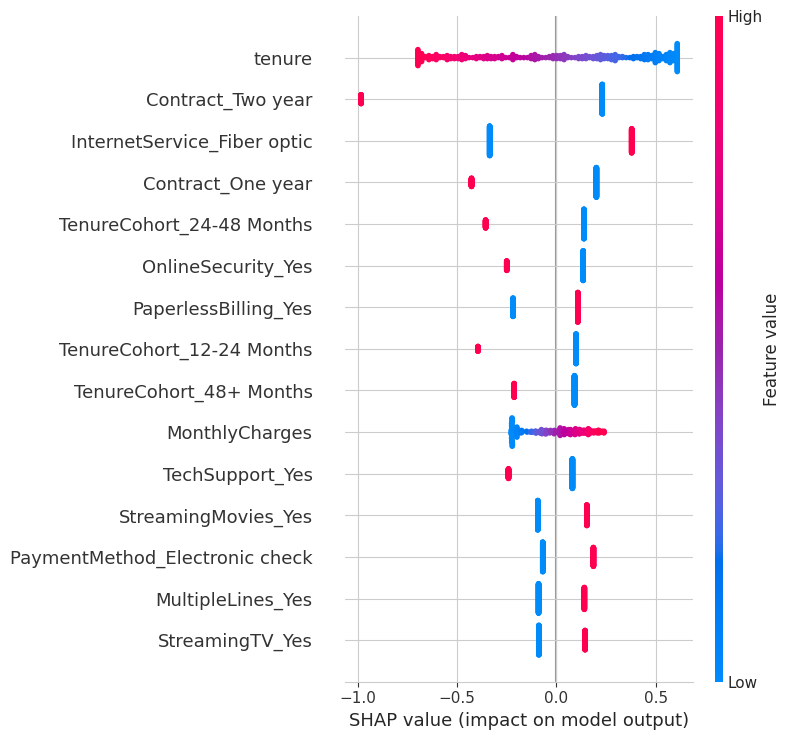

In [ ]:
# SHAP summary plot: distribution and direction of feature effects.
# Raw feature values are shown for interpretability; SHAP values come from the scaled model space.
shap.summary_plot(
    shap_values,
    shap_sample_raw,
    feature_names=FEATURE_NAMES,
    max_display=15,
    show=True
)


#### SHAP Summary Plot

Features near the top have larger overall contributions. Positive SHAP values push the Logistic Regression output towards higher churn odds; negative values push it lower. Values are on the model's <b>log-odds scale</b>, not probability percentage points.

/tmp/ipykernel_806/139447090.py:2: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



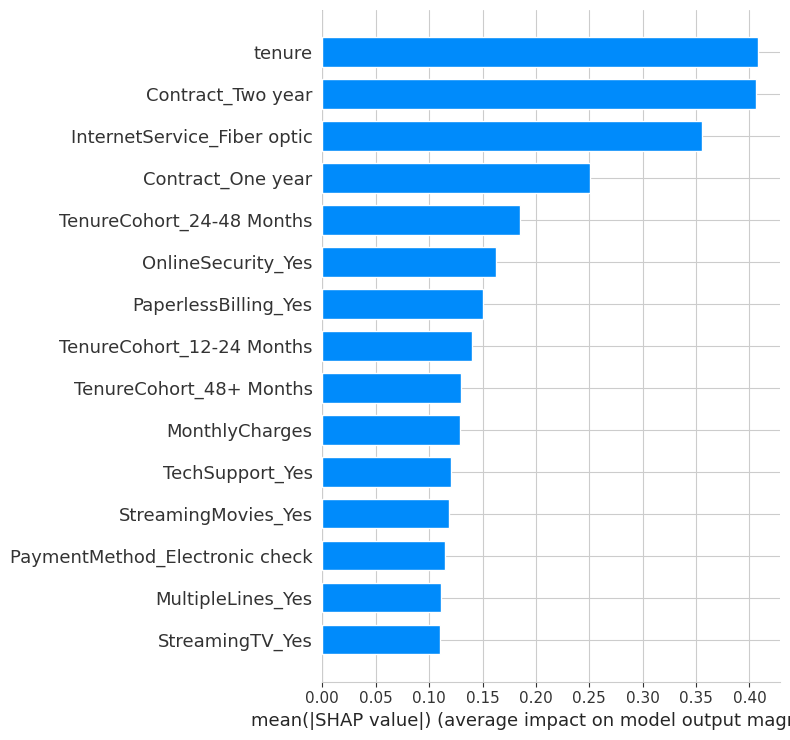

In [ ]:
# SHAP bar plot: mean absolute contribution (global importance)
shap.summary_plot(
    shap_values,
    shap_sample_raw,
    feature_names=FEATURE_NAMES,
    plot_type="bar",
    max_display=15,
    show=True
)


#### Global SHAP Importance

The bar plot ranks features by average absolute contribution. It shows how strongly a feature influences predictions on average, but not the direction of that influence.

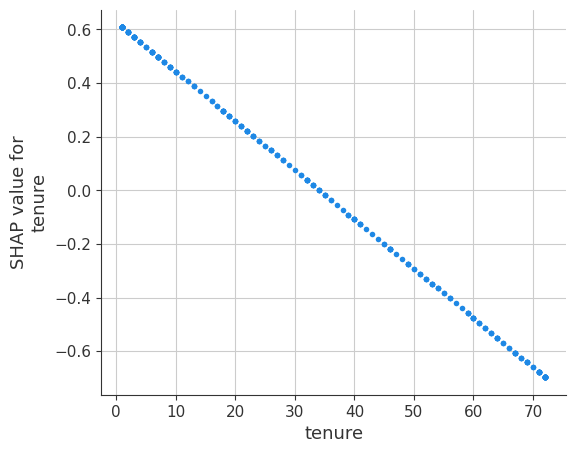

In [ ]:
# SHAP dependence plot for tenure using raw display values.
# No interaction feature is imposed because the explained classifier is linear.
shap.dependence_plot(
    "tenure",
    shap_values,
    shap_sample_raw,
    feature_names=FEATURE_NAMES,
    interaction_index=None,
    show=True
)

#### Tenure Dependence

The tenure plot shows the fitted association between tenure and the Logistic Regression output. It should not be interpreted as evidence that changing tenure would causally change churn.

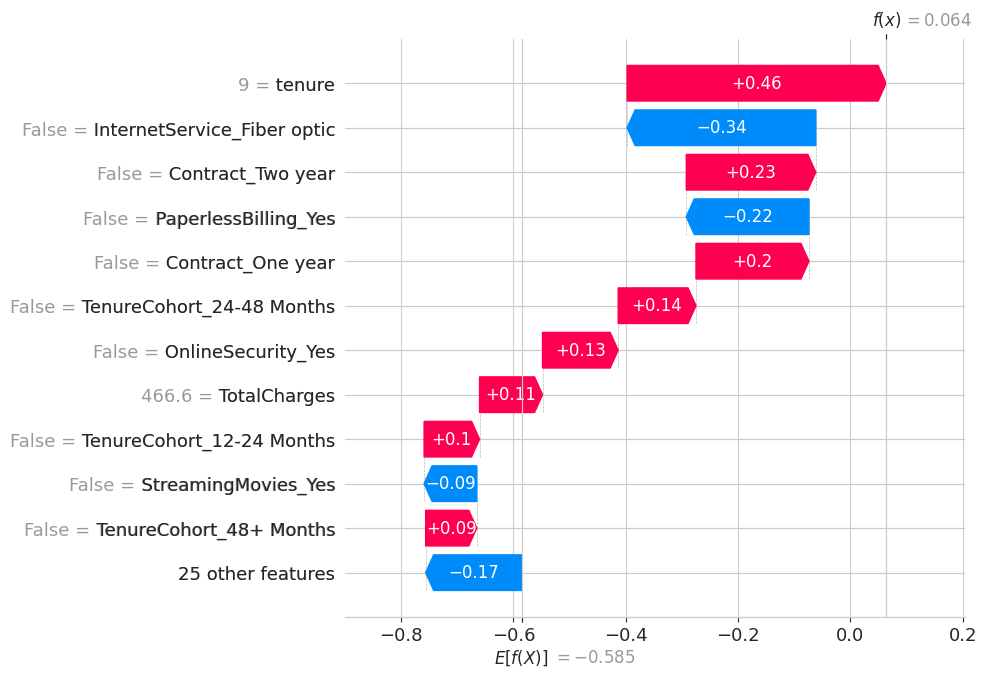

Predicted churn probability for this customer: 0.516


In [ ]:
# SHAP waterfall: explain one held-out customer's prediction
customer_idx = 0

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).reshape(-1)[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=float(base_value),
        data=shap_sample_raw.iloc[customer_idx].values,
        feature_names=FEATURE_NAMES
    ),
    max_display=12,
    show=True
)

customer_probability = shap_pipeline.predict_proba(
    shap_sample_raw.iloc[[customer_idx]]
)[0, 1]

print(
    f"Predicted churn probability for this customer: "
    f"{customer_probability:.3f}"
)


#### Individual Explanation

The waterfall plot explains one held-out prediction. It shows which observed features moved that customer's model score away from the baseline output.

---

# 12. Probability Calibration Diagnostic

Calibration asks whether predicted probabilities correspond reasonably to observed churn frequencies. This matters because threshold and business analyses use probabilities, not only class labels.

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.model_selection import learning_curve

# --- Calibration ---
fig_cal = go.Figure()
fig_cal.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Perfect calibration",
                             line=dict(dash="dash", color="grey")))
for name in final_candidates:
    frac_pos, mean_pred = calibration_curve(y_test, test_probs[name], n_bins=10, strategy="quantile")
    fig_cal.add_trace(go.Scatter(x=mean_pred, y=frac_pos, mode="lines+markers", name=name))

fig_cal.update_layout(title="Calibration Curves: Predicted vs Observed Churn Frequency",
                      xaxis_title="Mean Predicted Probability",
                      yaxis_title="Observed Churn Fraction",
                      template="plotly_white", height=480)
fig_cal.show()

#### Calibration Interpretation

The curves are diagnostic rather than proof of perfect calibration. They should be read together with the held-out <b>Brier score</b> and <b>log loss</b>.

---

# 13. Error Analysis

Aggregate metrics do not show which customers are affected. The selected Logistic Regression rule is therefore examined through false positives and false negatives.

In [ ]:
# Confusion matrix at the development-selected Logistic Regression threshold
error_model = "Logistic Regression"
err_proba = test_probs[error_model]
err_pred = (err_proba >= SELECTED_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, err_pred).ravel()

print(
    f"Confusion matrix for {error_model} "
    f"at threshold {SELECTED_THRESHOLD:.2f}"
)
print(f"True Negatives : {tn:4d}   False Positives: {fp:4d}")
print(f"False Negatives: {fn:4d}   True Positives : {tp:4d}")

Confusion matrix for Logistic Regression at threshold 0.56
True Negatives :  800   False Positives:  235
False Negatives:   98   True Positives :  276


In [ ]:
# Build an interpretable held-out error profile
error_df = df.loc[X_test.index].copy()
error_df["actual"] = y_test.values
error_df["predicted"] = err_pred
error_df["churn_probability"] = err_proba

error_df["outcome"] = np.select(
    [
        (error_df.actual == 1) & (error_df.predicted == 1),
        (error_df.actual == 0) & (error_df.predicted == 0),
        (error_df.actual == 0) & (error_df.predicted == 1),
        (error_df.actual == 1) & (error_df.predicted == 0)
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

profile = error_df.groupby("outcome").agg(
    Count=("actual", "size"),
    Avg_Tenure=("tenure", "mean"),
    Avg_Monthly=("MonthlyCharges", "mean"),
    Avg_Probability=("churn_probability", "mean")
).round(2)

profile

,Count,Avg_Tenure,Avg_Monthly,Avg_Probability
outcome,,,,
False Negative,98,28.28,61.94,0.37
False Positive,235,18.64,77.15,0.72
True Negative,800,43.04,56.19,0.21
True Positive,276,12.27,76.61,0.78


In [ ]:
# Contract mix by outcome: the clearest signal in the errors
contract_mix = pd.crosstab(error_df["outcome"], error_df["Contract"], normalize="index").round(3) * 100
print("Contract type distribution within each outcome (%):")
print(contract_mix.to_string())

print("\n--- Example FALSE NEGATIVES (churners the model missed, lowest predicted risk) ---")
worst_fn = error_df[error_df.outcome == "False Negative"].nsmallest(3, "churn_probability")
print(worst_fn[["tenure", "Contract", "MonthlyCharges", "InternetService",
                "PaymentMethod", "churn_probability"]].to_string())

print("\n--- Example FALSE POSITIVES (loyal customers wrongly flagged, highest predicted risk) ---")
worst_fp = error_df[error_df.outcome == "False Positive"].nlargest(3, "churn_probability")
print(worst_fp[["tenure", "Contract", "MonthlyCharges", "InternetService",
                "PaymentMethod", "churn_probability"]].to_string())

Contract type distribution within each outcome (%):
Contract        Month-to-month  One year  Two year
outcome                                           
False Negative            59.2      31.6       9.2
False Positive            97.0       3.0       0.0
True Negative             27.0      32.1      40.9
True Positive             98.2       1.8       0.0

--- Example FALSE NEGATIVES (churners the model missed, lowest predicted risk) ---
      tenure  Contract  MonthlyCharges InternetService              PaymentMethod  churn_probability
4386      55  Two year           57.55             DSL  Bank transfer (automatic)           0.031826
4513      72  Two year           92.45             DSL    Credit card (automatic)           0.048773
2894      48  One year           60.35             DSL    Credit card (automatic)           0.096391

--- Example FALSE POSITIVES (loyal customers wrongly flagged, highest predicted risk) ---
      tenure        Contract  MonthlyCharges InternetService   

#### Error Interpretation

False positives may create unnecessary retention reviews, while false negatives are genuine churners the model misses. The profiles help identify where the model struggles, but they do not establish the causes of those errors.

---

# 14. Fairness and Subgroup Diagnostic Audit

Overall performance can conceal subgroup differences. The selected Logistic Regression rule is therefore checked by gender and senior-citizen status.

In [ ]:
# Calculate subgroup performance metrics
fairness_rows = []
audit_df = df.loc[X_test.index]

for attribute, label in [
    ("gender", "Gender"),
    ("SeniorCitizen", "Senior Citizen")
]:
    for value in sorted(audit_df[attribute].unique()):
        mask = (audit_df[attribute] == value).values

        if mask.sum() < 30:
            continue

        yt = y_test[mask]
        yp = err_pred[mask]
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(
            yt,
            yp,
            labels=[0, 1]
        ).ravel()

        fairness_rows.append({
            "Attribute": label,
            "Group": str(value),
            "N": int(mask.sum()),
            "Actual_Churn_Rate": float(yt.mean()),
            "Selection_Rate": float(yp.mean()),
            "Accuracy": accuracy_score(yt, yp),
            "Precision": precision_score(yt, yp, zero_division=0),
            "Recall_TPR": recall_score(yt, yp, zero_division=0),
            "FPR": fp_g / (fp_g + tn_g) if (fp_g + tn_g) else np.nan,
            "F1": f1_score(yt, yp, zero_division=0)
        })

df_fairness = pd.DataFrame(fairness_rows).round(4)
df_fairness

,Attribute,Group,N,Actual_Churn_Rate,Selection_Rate,Accuracy,Precision,Recall_TPR,FPR,F1
0,Gender,Female,687,0.2809,0.3624,0.7613,0.5582,0.7202,0.2227,0.6290
1,Gender,Male,722,0.2507,0.3629,0.7659,0.5229,0.7569,0.2311,0.6185
2,Senior Citizen,0,1187,0.2325,0.3083,0.7776,0.5164,0.6848,0.1943,0.5888
3,Senior Citizen,1,222,0.4414,0.6532,0.6892,0.6000,0.8878,0.4677,0.7160


In [ ]:
# Summarise observed subgroup gaps
for attr in df_fairness["Attribute"].unique():
    sub = df_fairness[
        df_fairness["Attribute"] == attr
    ]

    print(
        f"{attr:15s} | "
        f"TPR gap={sub['Recall_TPR'].max() - sub['Recall_TPR'].min():.4f} | "
        f"FPR gap={sub['FPR'].max() - sub['FPR'].min():.4f} | "
        f"Selection-rate gap="
        f"{sub['Selection_Rate'].max() - sub['Selection_Rate'].min():.4f}"
    )

Gender          | TPR gap=0.0367 | FPR gap=0.0084 | Selection-rate gap=0.0005
Senior Citizen  | TPR gap=0.2030 | FPR gap=0.2734 | Selection-rate gap=0.3449


#### Fairness Interpretation

This is a <b>diagnostic audit</b>, not proof that the model is fair or unfair. Subgroup differences should be investigated alongside group size and churn prevalence before any real deployment.

---

# 15. Comparison Framework for Published Literature

Published results are used as context rather than direct rankings because data splits, preprocessing, resampling and thresholds can differ across studies.

In [ ]:
# Prepare this project's metrics for comparison with verified studies
project_literature_table = (
    df_metrics.loc[
        [
            "Logistic Regression",
            "Random Forest",
            "XGBoost",
            "MLP Neural Network"
        ],
        ["Accuracy", "F1", "ROC_AUC", "PR_AUC"]
    ]
    .copy()
)

project_literature_table.insert(
    0,
    "Dataset",
    "IBM Telco (7,043 rows)"
)
project_literature_table.insert(
    1,
    "Evaluation",
    "Held-out 20% test"
)

project_literature_table

,Dataset,Evaluation,Accuracy,F1,ROC_AUC,PR_AUC
Logistic Regression,"IBM Telco (7,043 rows)",Held-out 20% test,0.7367,0.6131,0.8400,0.6278
Random Forest,"IBM Telco (7,043 rows)",Held-out 20% test,0.7715,0.6073,0.8366,0.6428
XGBoost,"IBM Telco (7,043 rows)",Held-out 20% test,0.7729,0.6347,0.8423,0.6524
MLP Neural Network,"IBM Telco (7,043 rows)",Held-out 20% test,0.7367,0.5225,0.7684,0.5207


**Interpretation.** External values should only be added after checking the original paper's metric definition and experimental setup. Similar dataset names do not guarantee equivalent experiments.

---

# 16. Illustrative Business Scenario Analysis

The predictive outputs are translated into a hypothetical retention scenario. The purpose is to explore decision sensitivity under explicit assumptions, not to claim realised profit.

#### Scenario Assumptions

The dataset does not contain true customer lifetime value, retention-offer cost or intervention success. The following quantities are therefore labelled as <b>illustrative currency units (CU)</b> and a revenue-value proxy.

In [ ]:
# Explicit illustrative business assumptions
AVG_MONTHLY_REVENUE = float(df["MonthlyCharges"].mean())
EXPECTED_LIFETIME_MONTHS = 24
CUSTOMER_VALUE_PROXY = (
    AVG_MONTHLY_REVENUE * EXPECTED_LIFETIME_MONTHS
)
RETENTION_OFFER_COST = 50.0
OFFER_SUCCESS_RATE = 0.30

print("Scenario assumptions (illustrative CU)")
print(f"Average monthly charge : CU {AVG_MONTHLY_REVENUE:.2f}")
print(f"Assumed horizon        : {EXPECTED_LIFETIME_MONTHS} months")
print(f"Revenue-value proxy    : CU {CUSTOMER_VALUE_PROXY:.2f}")
print(f"Retention offer cost   : CU {RETENTION_OFFER_COST:.2f}")
print(f"Offer success rate     : {OFFER_SUCCESS_RATE:.0%}")

Scenario assumptions (illustrative CU)
Average monthly charge : CU 64.76
Assumed horizon        : 24 months
Revenue-value proxy    : CU 1554.28
Retention offer cost   : CU 50.00
Offer success rate     : 30%


In [ ]:
# Calculate illustrative campaign value for a decision rule
def campaign_value(
    y_true,
    y_pred,
    value_proxy,
    offer_cost,
    success_rate
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    value_saved_proxy = tp * success_rate * value_proxy
    campaign_cost = (tp + fp) * offer_cost
    lost_value_proxy = fn * value_proxy

    return {
        "Customers_Targeted": int(tp + fp),
        "Churners_Caught": int(tp),
        "Churners_Missed": int(fn),
        "Value_Saved_Proxy": value_saved_proxy,
        "Campaign_Cost": campaign_cost,
        "Incremental_Net_Value_Proxy": value_saved_proxy - campaign_cost,
        "Lost_Value_Proxy": lost_value_proxy
    }

In [ ]:
# Select the business threshold using OOF development predictions only
business_rows = []

for threshold in np.round(np.arange(0.05, 0.96, 0.01), 2):
    preds_dev = (oof_probs >= threshold).astype(int)

    result = campaign_value(
        y_train,
        preds_dev,
        CUSTOMER_VALUE_PROXY,
        RETENTION_OFFER_COST,
        OFFER_SUCCESS_RATE
    )

    result["Threshold"] = threshold
    result["Recall"] = recall_score(
        y_train,
        preds_dev,
        zero_division=0
    )
    business_rows.append(result)


df_business_dev = (
    pd.DataFrame(business_rows)
    .set_index("Threshold")
)
df_business_dev.index = df_business_dev.index.round(2)

BUSINESS_THRESHOLD = float(
    df_business_dev[
        "Incremental_Net_Value_Proxy"
    ].idxmax()
)

print(
    f"Development-selected business threshold: "
    f"{BUSINESS_THRESHOLD:.2f}"
)

display_thresholds = sorted(
    set([
        0.20,
        round(BUSINESS_THRESHOLD, 2),
        0.30,
        0.50,
        0.70
    ])
)

display(
    df_business_dev.loc[
        [t for t in display_thresholds if t in df_business_dev.index]
    ].round(2)
)

Development-selected business threshold: 0.26


,Customers_Targeted,Churners_Caught,Churners_Missed,Value_Saved_Proxy,Campaign_Cost,Incremental_Net_Value_Proxy,Lost_Value_Proxy,Recall
Threshold,,,,,,,,
0.20,3820,1437,58,670050.37,191000.0,479050.37,90148.28,0.96
0.26,3478,1411,84,657926.99,173900.0,484026.99,130559.57,0.94
0.30,3293,1383,112,644871.03,164650.0,480221.03,174079.43,0.93
0.50,2269,1184,311,552080.48,113450.0,438630.48,483381.27,0.79
0.70,1283,833,662,388414.73,64150.0,324264.73,1028933.77,0.56


#### Business Threshold

The business threshold is selected from <b>development OOF predictions</b>, not the test set. It is separate from the F1-optimal threshold because it optimises a different, explicitly assumed objective.

In [ ]:
# Evaluate the development-selected business threshold on the held-out test set
business_test_pred = (
    test_probs["Logistic Regression"] >= BUSINESS_THRESHOLD
).astype(int)

business_test_result = campaign_value(
    y_test,
    business_test_pred,
    CUSTOMER_VALUE_PROXY,
    RETENTION_OFFER_COST,
    OFFER_SUCCESS_RATE
)

print("Held-out business scenario (illustrative CU)")
print(
    f"Threshold selected on development data: "
    f"{BUSINESS_THRESHOLD:.2f}"
)

for key, value in business_test_result.items():
    if isinstance(value, float):
        if "Value" in key or "Cost" in key or "Saved" in key:
            print(f"{key:30s}: CU {value:,.2f}")
        else:
            print(f"{key:30s}: {value:.4f}")
    else:
        print(f"{key:30s}: {value}")

Held-out business scenario (illustrative CU)
Threshold selected on development data: 0.26
Customers_Targeted            : 871
Churners_Caught               : 354
Churners_Missed               : 20
Value_Saved_Proxy             : CU 165,064.60
Campaign_Cost                 : CU 43,550.00
Incremental_Net_Value_Proxy   : CU 121,514.60
Lost_Value_Proxy              : CU 31,085.61


In [ ]:
# Compare the model policy with simple decision baselines
target_none_pred = np.zeros(
    len(y_test),
    dtype=int
)
target_all_pred = np.ones(
    len(y_test),
    dtype=int
)

none_result = campaign_value(
    y_test,
    target_none_pred,
    CUSTOMER_VALUE_PROXY,
    RETENTION_OFFER_COST,
    OFFER_SUCCESS_RATE
)

all_result = campaign_value(
    y_test,
    target_all_pred,
    CUSTOMER_VALUE_PROXY,
    RETENTION_OFFER_COST,
    OFFER_SUCCESS_RATE
)

print("Decision-policy baselines")
print(
    f"No campaign     : CU "
    f"{none_result['Incremental_Net_Value_Proxy']:,.2f}"
)
print(
    f"Target everyone : CU "
    f"{all_result['Incremental_Net_Value_Proxy']:,.2f}"
)
print(
    f"Model policy    : CU "
    f"{business_test_result['Incremental_Net_Value_Proxy']:,.2f}"
)

Decision-policy baselines
No campaign     : CU 0.00
Target everyone : CU 103,940.29
Model policy    : CU 121,514.60


In [ ]:
# Sensitivity to the assumed retention-offer success rate
for rate in [0.10, 0.20, 0.30, 0.40, 0.50]:
    result_rate = campaign_value(
        y_test,
        business_test_pred,
        CUSTOMER_VALUE_PROXY,
        RETENTION_OFFER_COST,
        rate
    )

    print(
        f"Success rate {rate:.0%} -> "
        f"net value proxy CU "
        f"{result_rate['Incremental_Net_Value_Proxy']:,.0f}"
    )

Success rate 10% -> net value proxy CU 11,472
Success rate 20% -> net value proxy CU 66,493
Success rate 30% -> net value proxy CU 121,515
Success rate 40% -> net value proxy CU 176,536
Success rate 50% -> net value proxy CU 231,558


In [ ]:
# Descriptive risk profile by contract and internet service
segment_risk = (
    df.loc[X_test.index]
    .assign(prob=test_probs["Logistic Regression"])
    .groupby(["Contract", "InternetService"])
    .agg(
        Customers=("Churn", "size"),
        Actual_Churn_Rate=("Churn", "mean"),
        Mean_Predicted_Risk=("prob", "mean"),
        Avg_Monthly=("MonthlyCharges", "mean")
    )
    .sort_values(
        "Mean_Predicted_Risk",
        ascending=False
    )
    .round(3)
)

segment_risk

Customers  Actual_Churn_Rate  \
Contract       InternetService                                 
Month-to-month Fiber optic            421              0.527   
               DSL                    250              0.340   
One year       Fiber optic            103              0.223   
Month-to-month No                     102              0.216   
One year       DSL                    118              0.085   
Two year       Fiber optic             89              0.079   
One year       No                      79              0.038   
Two year       DSL                    116              0.017   
               No                     131              0.000   

                                Mean_Predicted_Risk  Avg_Monthly  
Contract       InternetService                                    
Month-to-month Fiber optic                    0.747       86.186  
               DSL                            0.528       50.712  
One year       Fiber optic                    0.409       97.601  
Month-to-month No                             0.333       20.267  
One year       DSL                            0.213       61.962  
Two year       Fiber optic                    0.194      104.897  
One year       No                             0.122       20.550  
Two year       DSL                            0.080       69.872  
               No                             0.048       21.701

#### Business Interpretation

The model policy is compared with targeting nobody and targeting everybody under the <b>same assumptions</b>. These figures remain scenario-based proxies; a real retention programme would require observed costs, customer value and experimental evidence of intervention effectiveness.

---

# 17. Reproducibility and Deployment Artefacts

The final section records the main software versions and persists the fitted Logistic Regression pipeline, selected threshold and aligned SHAP artefacts for later use in a deployment interface such as Streamlit.

In [ ]:
import sklearn
import joblib
import imblearn
import xgboost

print("Environment")
print(f"Python           : {sys.version.split()[0]}")
print(f"pandas           : {pd.__version__}")
print(f"scikit-learn     : {sklearn.__version__}")
print(f"imbalanced-learn : {imblearn.__version__}")
print(f"XGBoost          : {xgboost.__version__}")
print(f"SHAP             : {shap.__version__}")
print(f"Random seed      : {RANDOM_STATE}")

Environment
Python           : 3.12.13
pandas           : 2.2.3
scikit-learn     : 1.6.1
imbalanced-learn : 0.14.2
XGBoost          : 3.4.0
SHAP             : 0.52.0
Random seed      : 42


In [ ]:
# Refit the selected Logistic Regression specification on all development data
deployment_model = clone(
    best_models["Logistic Regression"]
)
deployment_model.fit(
    X_train,
    y_train
)

# Build SHAP artefacts from the same fitted model
deployment_scaler = deployment_model.named_steps["scaler"]
deployment_clf = deployment_model.named_steps["clf"]

deployment_background = pd.DataFrame(
    deployment_scaler.transform(X_train),
    columns=FEATURE_NAMES
).sample(
    min(500, len(X_train)),
    random_state=RANDOM_STATE
)

In [ ]:
# Persist model, explanation and environment artefacts
artefacts = {
    "model": deployment_model,
    "feature_names": FEATURE_NAMES,
    "threshold": SELECTED_THRESHOLD,
    "random_state": RANDOM_STATE,
    "training_columns": X_train.columns.tolist()
}

joblib.dump(
    artefacts,
    "churn_deployment_artefacts.joblib"
)

joblib.dump(
    {
        "model": deployment_clf,
        "scaler": deployment_scaler,
        "features": FEATURE_NAMES,
        "background": deployment_background
    },
    "churn_shap_artefacts.joblib"
)

env_snapshot = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "imbalanced_learn": imblearn.__version__,
    "xgboost": xgboost.__version__,
    "shap": shap.__version__,
    "random_state": RANDOM_STATE,
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "selected_threshold": SELECTED_THRESHOLD
}

with open("environment_snapshot.json", "w") as f:
    json.dump(env_snapshot, f, indent=2)

print("Saved deployment artefacts successfully.")

Saved deployment artefacts successfully.


#### Raw-Customer Preparation

The deployment helper recreates the same deterministic engineered features and aligns the resulting dummy variables to the exact training columns before prediction.

In [ ]:
def prepare_customer(customer_dict, training_columns):
    """Convert a raw customer record into a model-ready single-row frame.

    Applies the same deterministic feature engineering and one-hot encoding
    used in training, then reindexes to the exact training column order.
    """
    row = pd.DataFrame([customer_dict])

    service_cols = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]
    row["TotalServices"] = row[service_cols].apply(
        lambda r: sum(r == "Yes"), axis=1
    )

    row["TenureCohort"] = pd.cut(
        row["tenure"],
        bins=[-1, 12, 24, 48, np.inf],
        labels=["0-12 Months", "12-24 Months", "24-48 Months", "48+ Months"]
    )

    expected = row["MonthlyCharges"] * row["tenure"]
    row["ChargeRatio"] = np.where(
        expected > 0,
        row["TotalCharges"] / expected,
        1.0
    )

    row["AutoPayment"] = row["PaymentMethod"].isin(
        ["Bank transfer (automatic)", "Credit card (automatic)"]
    ).astype(int)

    cats = row.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    encoded = pd.get_dummies(row, columns=cats)

    return encoded.reindex(
        columns=training_columns,
        fill_value=0
    ).astype(float)


#### Prediction Interface

The prediction function loads the persisted model, applies the selected <b>0.56 threshold</b> and returns a small SHAP-based explanation from the same Logistic Regression classifier.

In [ ]:
def predict_churn(
    customer_dict,
    artefacts_path="churn_deployment_artefacts.joblib",
    shap_path="churn_shap_artefacts.joblib",
    top_k=5
):
    """Score one customer using the persisted model and aligned SHAP explanation."""

    art = joblib.load(artefacts_path)
    X_row = prepare_customer(
        customer_dict,
        art["training_columns"]
    )

    probability = float(
        art["model"].predict_proba(X_row)[0, 1]
    )
    threshold = float(art["threshold"])
    predicted_churn = probability >= threshold

    explanations = []
    try:
        sh = joblib.load(shap_path)
        X_scaled = pd.DataFrame(
            sh["scaler"].transform(X_row),
            columns=sh["features"]
        )

        local_explainer = shap.LinearExplainer(
            sh["model"],
            sh["background"]
        )
        vals = np.asarray(
            local_explainer.shap_values(X_scaled)
        )[0]

        contrib = pd.Series(
            vals,
            index=sh["features"]
        )
        order = contrib.abs().sort_values(
            ascending=False
        ).index[:top_k]

        for feat in order:
            val = float(contrib.loc[feat])
            explanations.append({
                "feature": feat,
                "impact": round(val, 4),
                "direction": (
                    "increases predicted risk"
                    if val > 0
                    else "reduces predicted risk"
                )
            })

    except Exception as exc:
        explanations = [{
            "feature": "explanation unavailable",
            "impact": 0.0,
            "direction": str(exc)
        }]

    # The threshold defines the operational flag. No arbitrary risk bands are imposed.
    if predicted_churn:
        action = "Flag for retention review; assess customer context before any intervention."
    else:
        action = "No model-triggered retention review at the selected operating threshold."

    return {
        "churn_probability": round(probability, 4),
        "predicted_churn": bool(predicted_churn),
        "threshold_used": threshold,
        "recommended_action": action,
        "top_factors": explanations,
        "causal_warning": (
            "Model explanations describe associations in predictions and "
            "do not establish that changing a feature will prevent churn."
        ),
    }


In [ ]:
# End-to-end high-risk-style interface check
example_customer = {
    "gender": "Female", "SeniorCitizen": 0,
    "Partner": "No", "Dependents": "No",
    "tenure": 2, "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No", "OnlineBackup": "No",
    "DeviceProtection": "No", "TechSupport": "No",
    "StreamingTV": "Yes", "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 94.5,
    "TotalCharges": 189.0,
}

result = predict_churn(example_customer)
print("High-risk-style example customer:")
print(json.dumps(result, indent=2))

High-risk-style example customer:
{
  "churn_probability": 0.9184,
  "predicted_churn": true,
  "threshold_used": 0.56,
  "recommended_action": "Flag for retention review; assess customer context before any intervention.",
  "top_factors": [
    {
      "feature": "tenure",
      "impact": 0.5899,
      "direction": "increases predicted risk"
    },
    {
      "feature": "InternetService_Fiber optic",
      "impact": 0.3789,
      "direction": "increases predicted risk"
    },
    {
      "feature": "Contract_Two year",
      "impact": 0.2307,
      "direction": "increases predicted risk"
    },
    {
      "feature": "Contract_One year",
      "impact": 0.2012,
      "direction": "increases predicted risk"
    },
    {
      "feature": "PaymentMethod_Electronic check",
      "impact": 0.1862,
      "direction": "increases predicted risk"
    }
  ],
  "causal_warning": "Model explanations describe associations in predictions and do not establish that changing a feature will prevent ch

In [ ]:
# Contrast with a low-risk customer, to confirm the model discriminates sensibly
loyal_customer = dict(example_customer)
loyal_customer.update({"tenure": 60, "Contract": "Two year", "InternetService": "DSL",
                       "MonthlyCharges": 45.0, "TotalCharges": 2700.0,
                       "PaymentMethod": "Credit card (automatic)",
                       "OnlineSecurity": "Yes", "TechSupport": "Yes"})

loyal_result = predict_churn(loyal_customer)
print("Low-risk example customer:")
print(json.dumps(loyal_result, indent=2))

print(f"\nDiscrimination check: {result['churn_probability']:.1%} (new, fibre, monthly) "
      f"vs {loyal_result['churn_probability']:.1%} (loyal, DSL, two-year)")

Low-risk example customer:
{
  "churn_probability": 0.0806,
  "predicted_churn": false,
  "threshold_used": 0.56,
  "recommended_action": "No model-triggered retention review at the selected operating threshold.",
  "top_factors": [
    {
      "feature": "Contract_Two year",
      "impact": -0.9835,
      "direction": "reduces predicted risk"
    },
    {
      "feature": "tenure",
      "impact": -0.4766,
      "direction": "reduces predicted risk"
    },
    {
      "feature": "InternetService_Fiber optic",
      "impact": -0.336,
      "direction": "reduces predicted risk"
    },
    {
      "feature": "OnlineSecurity_Yes",
      "impact": -0.2501,
      "direction": "reduces predicted risk"
    },
    {
      "feature": "TechSupport_Yes",
      "impact": -0.2413,
      "direction": "reduces predicted risk"
    }
  ],
  "causal_warning": "Model explanations describe associations in predictions and do not establish that changing a feature will prevent churn."
}

Discrimination check

#### Deployment Interpretation

The two synthetic customers are interface checks, not accuracy evidence. A production Streamlit application can call the persisted model and threshold, but real retention action would still require governance, business rules and validation of intervention effectiveness.

---

# 18. Evidence Summary and Limitations

The strongest conclusions should come from the executed development cross-validation, held-out metrics, error analysis and statistical comparisons.

Key limitations are:

- The IBM Telco dataset is a single fictional benchmark snapshot, so external validity to a live provider is unknown.
- SMOTE can generate fractional values for one-hot indicators; the final Logistic Regression model therefore uses class weighting instead.
- The MLP provides a neural baseline, but this project does not claim to benchmark every modern deep-learning architecture.
- SHAP and observed feature associations are <b>not causal treatment effects</b>.
- Business-value figures use assumed costs, a revenue-value proxy and an assumed intervention-success rate; they are scenario analysis, not realised profit or EMPC.
- Fairness results are subgroup diagnostics on the held-out sample, not a certification of fairness.

> <b>Final principle:</b> No model, feature or intervention is treated as universally optimal beyond the evidence produced by this experimental design.